# Week 06 — EDA Precision Lab

## Part A — Dataset Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


## Dataset Shape

Check the number of rows and columns in the dataset.

In [2]:
students.shape

(600, 6)

## Dataset Information

Check the column names, data types, and non-null values.

In [3]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    object 
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.2+ KB


## Missing Values

Check whether the dataset contains any missing values.

In [4]:
students.isnull().sum()

student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

## Duplicate Rows

Check whether the dataset contains any duplicate rows.

In [5]:
students.duplicated().sum()

np.int64(0)

## Descriptive Statistics

Review the basic statistical summary of the numerical variables.

In [6]:
students.describe()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000


## 2. Genuine Relationship — Study Hours vs Exam Score

Does study time have a relationship with exam score?
A scatter plot is appropriate because both study hours and exam score are continuous numerical variables. Pearson correlation will be used to measure the strength and direction of their linear relationship.

In [7]:
r_study = students["study_hours_per_week"].corr(students["exam_score"])

print(f"Pearson correlation (r): {r_study:.4f}")

Pearson correlation (r): 0.6895


### Pearson Correlation

The Pearson correlation between study hours per week and exam score is **r = 0.6895**, indicating a moderate positive linear relationship between the two variables.

### Study Hours vs Exam Score — Scatter Plot

A scatter plot is used to visualize the relationship between study hours per week and exam score. A fitted trend line is added to show the overall direction of the relationship.

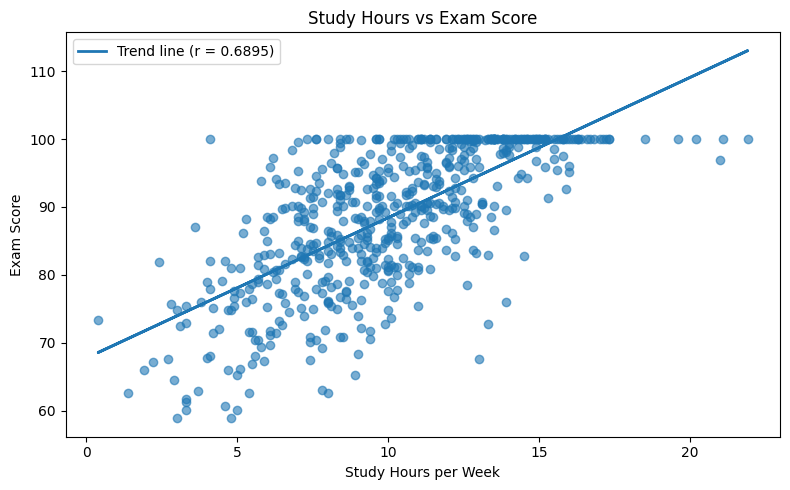

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()

fig.savefig("Figures/study_hours_vs_exam_score.png", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
study_finding = (
    f"Study hours per week and exam score show a moderate positive linear "
    f"relationship, with a Pearson correlation of r = {r_study:.4f}. "
    f"This indicates that students who study more hours per week tend to "
    f"have higher exam scores in this dataset."
)

print(study_finding)

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.


## Finding

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.

## Finding

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.

## 3. Null Relationship — Sleep Hours vs Exam Score

Does sleep time have a meaningful relationship with exam score?

A scatter plot is appropriate because both sleep hours and exam score are continuous numerical variables. Pearson correlation will be used to determine the strength and direction of their linear relationship.

In [10]:
r_sleep = students["sleep_hours_per_night"].corr(students["exam_score"])

print(f"Pearson correlation (r): {r_sleep:.4f}")

Pearson correlation (r): -0.0217


### Pearson Correlation

The Pearson correlation between sleep hours per night and exam score is **r = -0.0217**, indicating a negligible linear relationship between the two variables.

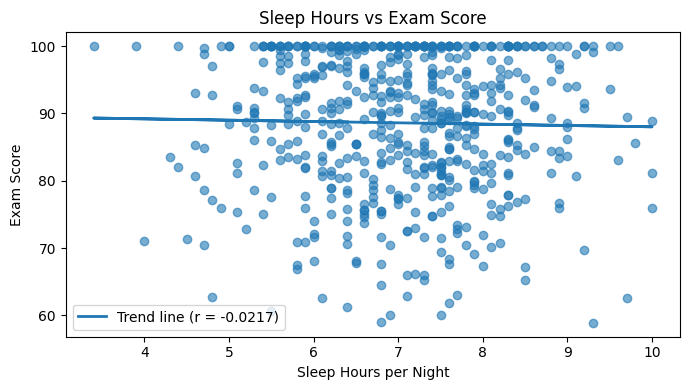

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(
    students["sleep_hours_per_night"],
    students["exam_score"],
    alpha=0.6
)

x = students["sleep_hours_per_night"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_sleep:.4f})"
)

ax.set_title("Sleep Hours vs Exam Score")
ax.set_xlabel("Sleep Hours per Night")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figures/sleep_hours_vs_exam_score.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [12]:
sleep_finding = (
    f"Sleep hours per night show no meaningful linear relationship with exam score "
    f"in this dataset, with a Pearson correlation of r = {r_sleep:.4f}. "
    f"The near-zero correlation indicates that variation in sleep hours is not "
    f"linearly associated with variation in exam scores in this dataset."
)

print(sleep_finding)

Sleep hours per night show no meaningful linear relationship with exam score in this dataset, with a Pearson correlation of r = -0.0217. The near-zero correlation indicates that variation in sleep hours is not linearly associated with variation in exam scores in this dataset.


## Finding

Sleep hours per night show no meaningful linear relationship with exam score in this dataset, with a Pearson correlation of r = -0.0217. The near-zero correlation indicates that variation in sleep hours is not linearly associated with variation in exam scores in this dataset.

## 4. Genuine Comparison — Exam Score by Class Section

How do exam scores compare across class sections?

A bar chart is appropriate because class section is a categorical variable and exam score is a continuous numerical variable. The sections can be compared regardless of their order, so this is a categorical comparison rather than a relationship.

In [13]:
section_means = students.groupby("class_section")["exam_score"].mean()

print(section_means)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


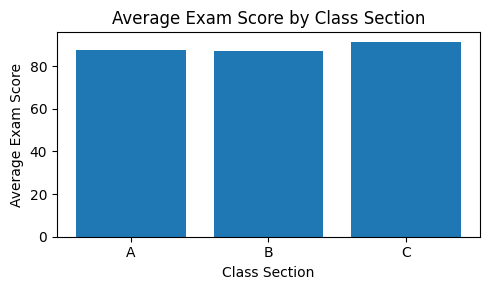

In [14]:
section_means = section_means.reindex(["A", "B", "C"])

fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/exam_score_by_class_section.png",
    dpi=100
)

plt.show()
plt.close(fig)

In [15]:
section_means = students.groupby("class_section")["exam_score"].mean()

print(section_means)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


In [16]:
shuffled_means = section_means.reindex(["C", "A", "B"])

print(shuffled_means)

class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


In [17]:
section_means = students.groupby("class_section")["exam_score"].mean()

mean_a = section_means.loc["A"]
mean_b = section_means.loc["B"]
mean_c = section_means.loc["C"]

ab_difference = abs(mean_a - mean_b)
c_vs_a = mean_c - mean_a
c_vs_b = mean_c - mean_b

print("### Findings")
print(
    f"- Section C has the highest average exam score ({mean_c:.2f}), "
    f"followed by Section A ({mean_a:.2f}) and Section B ({mean_b:.2f})."
)
print(
    f"- Sections A and B have very similar average scores, "
    f"with a difference of only {ab_difference:.2f} points."
)
print(
    f"- Section C's average is {c_vs_a:.2f} points higher than A "
    f"and {c_vs_b:.2f} points higher than B."
)

### Findings
- Section C has the highest average exam score (91.36), followed by Section A (87.61) and Section B (87.03).
- Sections A and B have very similar average scores, with a difference of only 0.58 points.
- Section C's average is 3.75 points higher than A and 4.34 points higher than B.


## Findings

- Section C has the highest average exam score (91.36), followed by Section A (87.61) and Section B (87.03).

- Sections A and B have very similar average scores, with a difference of only 0.58 points.

- Section C's average is 3.75 points higher than A and 4.34 points higher than B.

## 5. The Line-Chart Trap
What false impression is created when category averages are connected with a line?

A line chart will be intentionally used on the class-section averages to demonstrate why connecting unordered categories can be misleading.

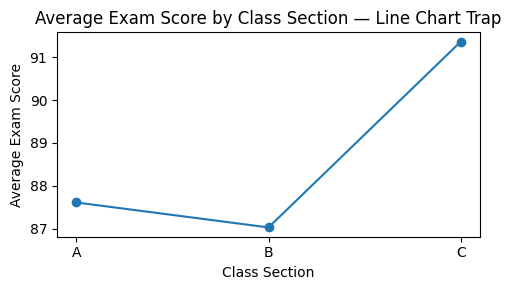

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(
    section_means.index,
    section_means.values,
    marker="o"
)

ax.set_title("Average Exam Score by Class Section — Line Chart Trap")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/class_section_line_chart_trap.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Finding

The line chart creates a false impression of a continuous trend between Sections A, B, and C. The upward or downward movement of the line suggests that exam scores change progressively from one section to the next, even though class sections are unordered categories. The bar chart is more appropriate because it compares the average exam scores of separate groups without implying movement or continuity between them.

### Shuffle Test

The category order is changed from A → B → C to C → A → B to verify whether changing the order changes the visual pattern of the line chart.

In [19]:
shuffled_means = section_means.reindex(["C", "A", "B"])

print("Original order:")
print(section_means)

print("\nShuffled order:")
print(shuffled_means)

Original order:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

Shuffled order:
class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


## 5. The Line-Chart Trap — Original vs Shuffled Order

A line chart is intentionally used to connect the mean exam scores of the categorical variable `class_section`. The category order is then changed from A → B → C to C → A → B. This demonstrates how changing the order of unordered categories changes the visual pattern of the line, even though the underlying values remain unchanged.

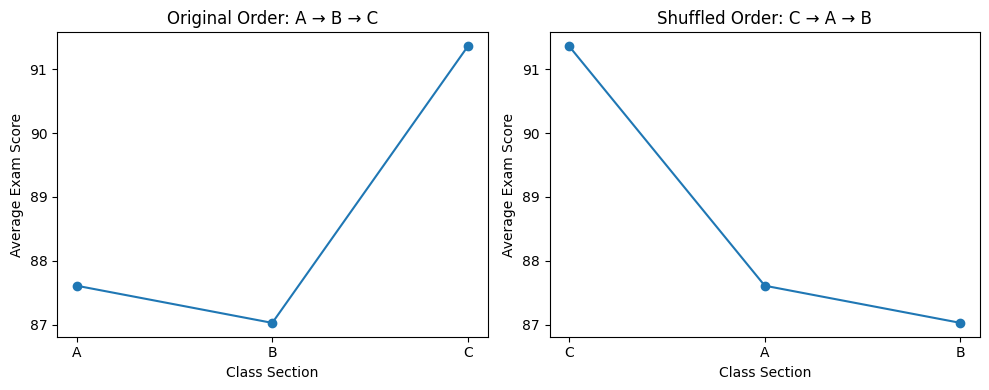

In [20]:
shuffled_means = section_means.reindex(["C", "A", "B"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original order
axes[0].plot(
    section_means.index,
    section_means.values,
    marker="o"
)

axes[0].set_title("Original Order: A → B → C")
axes[0].set_xlabel("Class Section")
axes[0].set_ylabel("Average Exam Score")

# Shuffled order
axes[1].plot(
    shuffled_means.index,
    shuffled_means.values,
    marker="o"
)

axes[1].set_title("Shuffled Order: C → A → B")
axes[1].set_xlabel("Class Section")
axes[1].set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/class_section_line_chart_trap_comparison.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Finding

The two line charts contain the same average exam scores, but changing the category order changes the visual pattern of the line. In the original A → B → C order, the chart appears to show a dip from A to B followed by an increase to C. After changing the order to C → A → B, a different pattern appears even though none of the underlying values changed. This demonstrates the false impression created by connecting unordered categories with a line. A bar chart is therefore more appropriate for comparing average exam scores across class sections.

## 6. Visual QA — Deliberate Layout Collision

A chart is not complete when it only looks correct inside the notebook. The saved PNG must also be checked at its actual size. In this step, an annotation will intentionally be placed where it overlaps another chart element, and the layout will then be fixed.

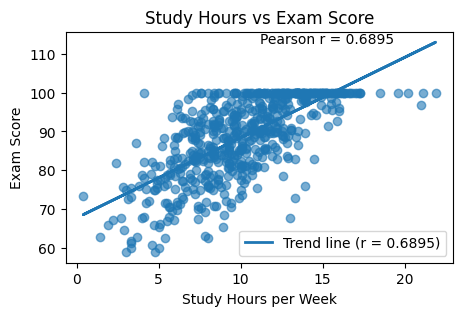

In [21]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Deliberately place annotation where it may overlap
ax.text(
    0.5,
    0.95,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=10
)

fig.savefig(
    "Figures/study_hours_layout_broken.png",
    dpi=100
)

plt.show()
plt.close(fig)

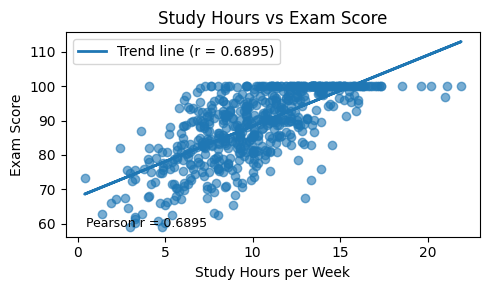

In [22]:
## FIX THe above issue
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Repositioned annotation
ax.text(
    0.05,
    0.05,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=9
)

fig.tight_layout()

fig.savefig(
    "Figures/study_hours_layout_fixed.png",
    dpi=100
)

plt.show()
plt.close(fig)

## 7. Color and Category Order

Color and category order can affect how a comparison chart is interpreted. In this step, the same comparison will be shown with arbitrary colors and then with a consistent color choice. The class sections will remain in their natural order: A, B, C, rather than being sorted by their mean scores.

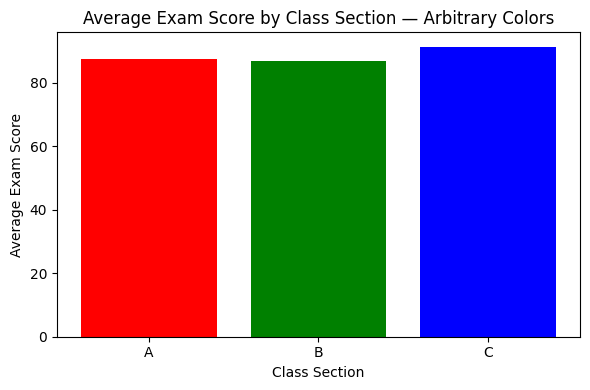

In [23]:
## ARbitrary color chart
section_means = students.groupby("class_section")["exam_score"].mean()

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]],
    color=["red", "green", "blue"]
)

ax.set_title("Average Exam Score by Class Section — Arbitrary Colors")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_arbitrary_colors.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Arbitrary Colors

This version deliberately uses different arbitrary colors for each class section. The colors do not represent any meaningful property of the data, such as score level, priority, or category type. This is included to demonstrate why arbitrary colors should generally be avoided in a categorical comparison chart when color is not encoding additional information.

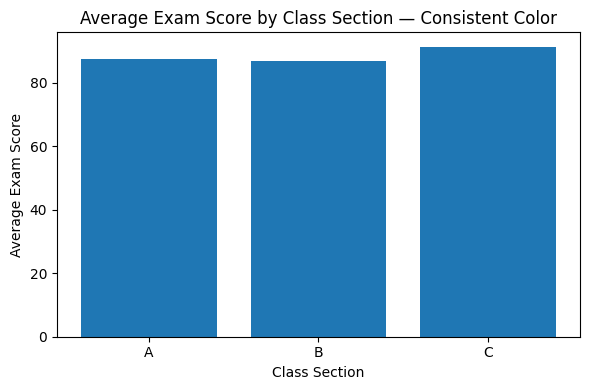

In [24]:

## Correct Color usage
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Average Exam Score by Class Section — Consistent Color")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_consistent_color.png",
    dpi=100
)

plt.show()
plt.close(fig)

## Step 7 Findings — Color and Category Order

The arbitrary-color chart uses different colors for each class section, but the colors do not provide any additional information. This can make the chart visually distracting and may imply differences that are not actually meaningful.

The consistent-color chart is clearer because the same visual treatment is used for all sections. Since color is not representing another variable, using one consistent color avoids unnecessary visual emphasis.

The category order remains A → B → C in both charts. This preserves the natural order of the class sections instead of sorting them by their average exam scores.

## 8. Labels and Readability

Clear labels are important because they help the reader understand what each axis and category represents. A chart should not require the reader to guess the meaning of its values or labels.

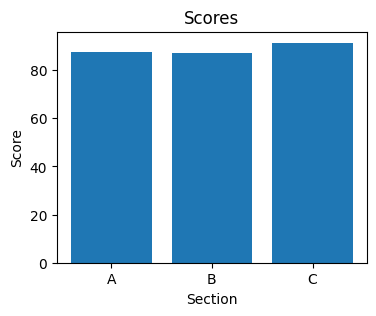

In [25]:
## Poor labeling
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Scores")
ax.set_xlabel("Section")
ax.set_ylabel("Score")

fig.savefig(
    "Figures/section_comparison_poor_readability.png",
    dpi=100
)

plt.show()
plt.close(fig)

### 8.1 Comparison Chart — Poor Readability

This version intentionally uses a small figure size and generic labels to demonstrate a readability problem. The title and axis labels do not clearly describe the information being presented, so the reader has to infer what the scores represent.

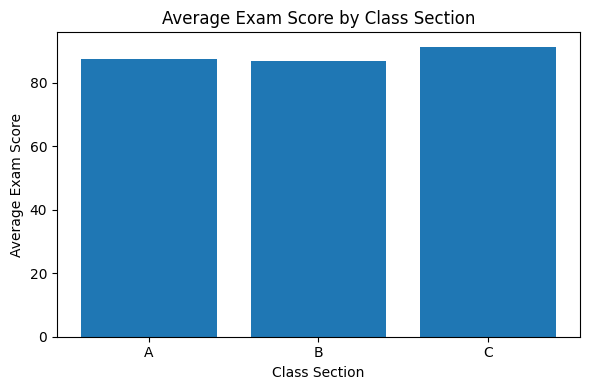

In [26]:
## Improved label and readability
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_improved_readability.png",
    dpi=100
)

plt.show()
plt.close(fig)

## Step 8 Findings — Labels and Readability

The poor-readability version uses a small figure and generic labels such as "Scores" and "Section". Although the chart is still understandable, the labels do not provide enough context and the layout is less comfortable to read.

The improved version uses a larger figure and descriptive labels. The title clearly identifies the comparison, while the x-axis and y-axis labels explain the class sections and average exam scores.

This shows that clear labels, appropriate figure size, and proper layout are important for making charts easy to understand without requiring additional explanation.

## Final Visual QA Findings

The visualizations were reviewed using the saved PNG files rather than relying only on the notebook display.

The comparison charts maintain the natural category order A → B → C. The color comparison showed that arbitrary colors can add unnecessary visual emphasis, while a consistent color provides a cleaner presentation.

The readability comparison showed that descriptive titles, meaningful axis labels, appropriate figure size, and proper layout make the chart easier to understand.

The final visual QA also confirmed that the saved figures should be checked for clipping, overlapping elements, and other layout issues before they are considered complete.

Overall, the visualization process demonstrates that creating a chart is not enough; the final output should also be visually inspected and validated.

## Step 8 — Self-Audit

The reported findings are verified by independently recomputing the two Pearson correlations and one section mean. The claimed values are compared with freshly recomputed values to ensure that every number reported in the findings matches the data.

In [27]:
# Fresh independent recomputation

audit_study_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

audit_sleep_r = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

audit_section_a_mean = students.loc[
    students["class_section"] == "A",
    "exam_score"
].mean()

self_audit = pd.DataFrame({
    "Metric": [
        "Study Hours vs Exam Score Correlation",
        "Sleep Hours vs Exam Score Correlation",
        "Section A Mean Exam Score"
    ],
    "Claimed Value": [
        r_study,
        r_sleep,
        mean_a
    ],
    "Freshly Recomputed Value": [
        audit_study_r,
        audit_sleep_r,
        audit_section_a_mean
    ]
})

self_audit["Match"] = (
    self_audit["Claimed Value"] == self_audit["Freshly Recomputed Value"]
)

self_audit

,Metric,Claimed Value,Freshly Recomputed Value,Match
0,Study Hours vs Exam Score Correlation,0.689476,0.689476,True
1,Sleep Hours vs Exam Score Correlation,-0.021658,-0.021658,True
2,Section A Mean Exam Score,87.608491,87.608491,True


## 9. Correlation vs. Causation

A correlation between study hours and exam score does not prove that studying more causes higher exam scores. A third variable, such as student motivation, could influence both study time and exam performance, making it a plausible confounding variable.

### Confounding Variable

Student motivation is a plausible confounding variable because highly motivated students may spend more time studying and may also perform better in exams for other reasons not directly captured by study hours.

Therefore, the observed correlation should be described as an association rather than a causal effect.

In [28]:
correlation_finding = (
    f"Students who reported more study hours per week tended to have higher "
    f"exam scores, with a Pearson correlation of r = {r_study:.4f}. "
    f"This shows a positive association, but it does not prove that studying "
    f"more directly causes higher exam scores."
)

print(correlation_finding)

Students who reported more study hours per week tended to have higher exam scores, with a Pearson correlation of r = 0.6895. This shows a positive association, but it does not prove that studying more directly causes higher exam scores.


## 10. Pearson vs. Spearman Correlation

Pearson correlation measures the strength of a linear relationship between two numeric variables. Spearman correlation measures whether the relationship is consistently monotonic based on the ranks of the observations.

Both methods will be computed for study hours and exam score so that their results can be compared rather than assuming in advance that they will be similar.

### Why Compare Both Methods?

Pearson correlation alone is not sufficient because it specifically measures linear association and may not fully describe a curved but consistent relationship. Spearman correlation alone is also not sufficient for this task because the purpose of this step is to compare the linear Pearson measure with the rank-based Spearman measure.

Computing both methods allows us to check whether the relationship gives a similar result under both approaches.

In [29]:
pearson_r = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="pearson"
)

print(f"Pearson correlation: {pearson_r:.4f}")

Pearson correlation: 0.6895


In [30]:
pearson_finding = (
    f"The Pearson correlation between study hours per week and exam score "
    f"was r = {pearson_r:.4f}, indicating a moderately strong positive linear association."
)

print(pearson_finding)

The Pearson correlation between study hours per week and exam score was r = 0.6895, indicating a moderately strong positive linear association.


### Pearson Correlation Finding

The Pearson correlation indicates a moderately strong positive linear association between study hours per week and exam score. Students with higher reported study hours tended to have higher exam scores, although this correlation does not establish a causal relationship.

In [31]:
spearman_r = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="spearman"
)

print(f"Spearman correlation: {spearman_r:.4f}")

Spearman correlation: 0.7010


In [32]:
spearman_finding = (
    f"The Spearman correlation between study hours per week and exam score "
    f"was r = {spearman_r:.4f}, indicating a moderately strong positive "
    f"monotonic association."
)

print(spearman_finding)

The Spearman correlation between study hours per week and exam score was r = 0.7010, indicating a moderately strong positive monotonic association.


### Comparing Pearson and Spearman

Pearson and Spearman correlations should be compared directly rather than assuming that they are similar. Calculating their absolute difference provides an objective way to describe how close the two correlation estimates are.

The absolute difference is used because the purpose is to measure the distance between the two values, not which correlation is larger. Using `abs()` removes the direction of the difference while preserving its magnitude.

In [33]:
correlation_difference = abs(pearson_r - spearman_r)

print(
    f"Absolute difference between Pearson and Spearman: "
    f"{correlation_difference:.4f}"
)

Absolute difference between Pearson and Spearman: 0.0115


In [34]:
if correlation_difference < 0.05:
    comparison_result = "The Pearson and Spearman correlations are close to each other."
else:
    comparison_result = "The Pearson and Spearman correlations differ noticeably."

comparison_finding = (
    f"Pearson correlation was {pearson_r:.4f}, while Spearman correlation was "
    f"{spearman_r:.4f}. The absolute difference was "
    f"{correlation_difference:.4f}. {comparison_result}"
)

print(comparison_finding)


Pearson correlation was 0.6895, while Spearman correlation was 0.7010. The absolute difference was 0.0115. The Pearson and Spearman correlations are close to each other.


### Pearson vs. Spearman Finding

The Pearson and Spearman correlations are close to each other, indicating that the positive relationship between study hours and exam score is broadly consistent when measured as a linear association and as a rank-based monotonic association.

If the two correlations had differed substantially, it would have been a reason to investigate the scatter plot for a curved but consistently increasing relationship, because Pearson can understate a non-linear monotonic pattern.

## 11. Bootstrap Confidence Interval for the Section Gap

The comparison chart shows that the mean exam scores of Section A and Section C differ, but a visual difference alone does not tell us whether the observed gap could reasonably be explained by sampling variation.

A bootstrap confidence interval provides a way to quantify the uncertainty around the difference in group means. We will repeatedly resample the observations with replacement, calculate the difference in mean exam score for each resample, and use the resulting distribution to estimate a 95% confidence interval.

If the confidence interval excludes zero, the observed difference is inconsistent with zero at this confidence level. If the interval includes zero, a zero difference remains plausible based on this analysis.

In [35]:
students.groupby("class_section")["exam_score"].mean()

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

### Preparing Section A and Section C Data

The bootstrap procedure requires the individual exam-score observations from Section A and Section C rather than only their group means. Keeping the individual observations preserves the variation within each section, which is necessary for resampling with replacement and estimating the uncertainty around the difference in means.

Using only the previously calculated group means would remove this within-group variation and would therefore not provide a valid bootstrap confidence interval.

In [36]:
section_a = students.loc[
    students["class_section"] == "A", "exam_score"
].to_numpy()

section_c = students.loc[
    students["class_section"] == "C", "exam_score"
].to_numpy()

print(f"Section A observations: {len(section_a)}")
print(f"Section C observations: {len(section_c)}")

Section A observations: 212
Section C observations: 190


### Defining the Bootstrap Statistic

The quantity of interest is the difference in mean exam score between Section A and Section C. A custom statistic function is used so that each bootstrap resample produces the same quantity: the mean score of Section A minus the mean score of Section C.

Using a statistic based on the individual observations allows the bootstrap procedure to capture variation within both sections.

In [37]:
def mean_difference(a, c, axis=-1):
    return np.mean(a, axis=axis) - np.mean(c, axis=axis)

### Why Define a Custom Statistic Function?

The bootstrap method needs a statistic to calculate repeatedly for every resampled dataset. In this analysis, the statistic of interest is the difference in mean exam score between Section A and Section C.

A custom function is therefore defined to calculate the mean of Section A minus the mean of Section C for each bootstrap resample. This keeps the statistical quantity consistent throughout the bootstrap procedure and allows `scipy.stats.bootstrap` to repeatedly recompute the same mean difference.

### Why Not Use a Simpler Calculation?

Using only `section_a.mean() - section_c.mean()` would calculate the observed difference between the two original group means only once. It would not allow the bootstrap procedure to recalculate the difference for every resampled dataset.

Therefore, a custom statistic function is used so that the same mean-difference calculation can be repeatedly applied to the bootstrap resamples.

### Computing the Bootstrap Confidence Interval

The bootstrap procedure repeatedly resamples the individual exam scores from Section A and Section C with replacement. For each resample, the custom statistic function calculates the difference in their mean exam scores.

The distribution of these resampled differences is then used to estimate a 95% confidence interval. This interval shows the range of mean differences that is reasonably supported by the bootstrap procedure.

In [38]:
bootstrap_result = stats.bootstrap(
    (section_a, section_c),
    mean_difference,
    confidence_level=0.95,
    n_resamples=10000,
    random_state=21
)

ci_low = bootstrap_result.confidence_interval.low
ci_high = bootstrap_result.confidence_interval.high

observed_difference = mean_difference(section_a, section_c)

print(f"Observed mean difference (A - C): {observed_difference:.4f}")
print(f"95% bootstrap CI lower bound: {ci_low:.4f}")
print(f"95% bootstrap CI upper bound: {ci_high:.4f}")

Observed mean difference (A - C): -3.7541
95% bootstrap CI lower bound: -5.7234
95% bootstrap CI upper bound: -1.8329


### Bootstrap Confidence Interval Interpretation

The observed mean difference is calculated as Section A minus Section C. Because the observed difference is negative, Section A has a lower mean exam score than Section C in the observed data.

The 95% bootstrap confidence interval extends from a negative lower bound to a negative upper bound. Because the entire interval is below zero, the estimated difference consistently favors a higher mean exam score for Section C rather than Section A.

This provides statistical evidence that the observed Section A versus Section C gap is different from zero at the 95% confidence level. However, this result describes an association between section membership and exam scores and does not by itself establish that being in a particular section causes higher exam performance.

### Checking Whether the Confidence Interval Includes Zero

Zero represents no difference between the mean exam scores of Section A and Section C. Therefore, checking whether zero falls inside the bootstrap confidence interval determines whether a zero mean difference remains plausible according to the interval.

This check is performed directly from the computed confidence interval rather than being judged visually from the comparison chart.

In [39]:
ci_includes_zero = ci_low <= 0 <= ci_high

print(f"Does the 95% confidence interval include zero? {ci_includes_zero}")

Does the 95% confidence interval include zero? False


In [40]:
bootstrap_finding = (
    f"The observed mean difference between Section A and Section C "
    f"(A - C) was {observed_difference:.4f}, with a 95% bootstrap confidence "
    f"interval from {ci_low:.4f} to {ci_high:.4f}. "
    f"The confidence interval does not include zero, indicating that the "
    f"observed mean difference is supported as being different from zero "
    f"at the 95% confidence level."
)

print(bootstrap_finding)

The observed mean difference between Section A and Section C (A - C) was -3.7541, with a 95% bootstrap confidence interval from -5.7234 to -1.8329. The confidence interval does not include zero, indicating that the observed mean difference is supported as being different from zero at the 95% confidence level.


### Bootstrap Finding

The bootstrap analysis provides statistical evidence that the mean exam scores of Section A and Section C differ. Because the confidence interval does not include zero, a zero difference between the two section means is not supported by this interval.

This strengthens the comparison shown by the chart because the conclusion is based on both the observed difference and its uncertainty rather than on visual separation alone.

## 12. Small Multiples — Study Hours vs. Exam Score by Section

A small-multiples figure repeats the same relationship chart for each category so that the relationship can be compared across groups without implying an order between the categories.

Each panel will show study hours per week against exam score for one class section. The panels will share the same x- and y-axis scales so that the strength and direction of the relationships can be compared fairly.

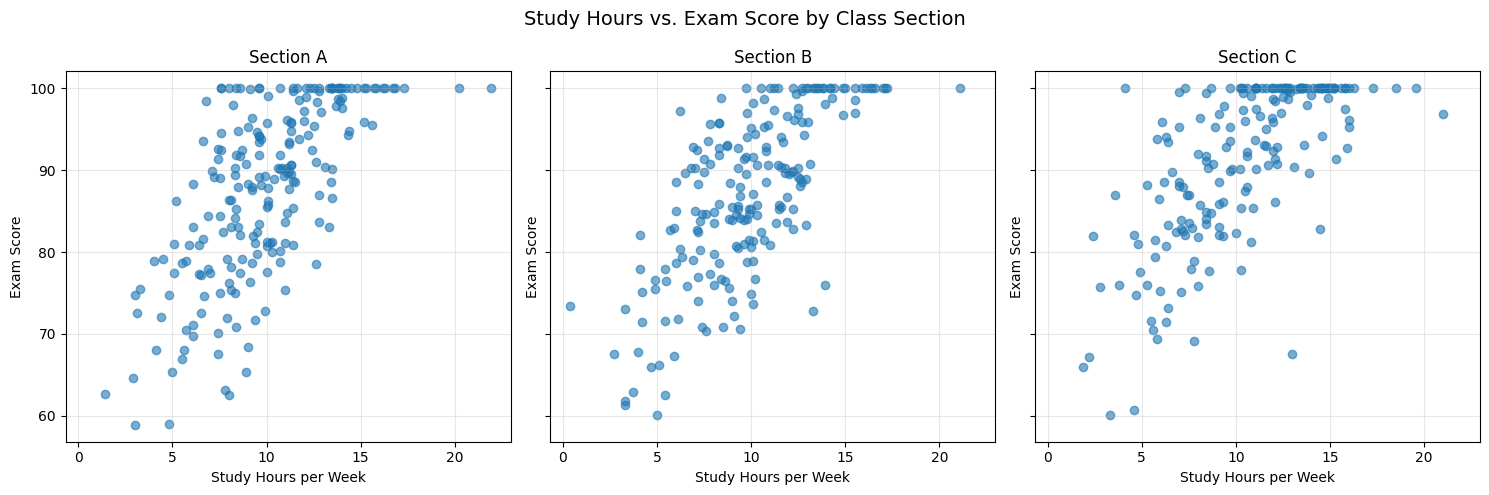

In [41]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

sections = ["A", "B", "C"]

for ax, section in zip(axes, sections):
    section_data = students[students["class_section"] == section]

    ax.scatter(
        section_data["study_hours_per_week"],
        section_data["exam_score"],
        alpha=0.6
    )

    ax.set_title(f"Section {section}")
    ax.set_xlabel("Study Hours per Week")
    ax.set_ylabel("Exam Score")
    ax.grid(alpha=0.3)

fig.suptitle(
    "Study Hours vs. Exam Score by Class Section",
    fontsize=14
)

fig.tight_layout()
plt.show()

In [42]:
figure_path = "Figures/small_multiples_sections.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

print(f"Small-multiples figure saved to: {figure_path}")

Small-multiples figure saved to: Figures/small_multiples_sections.png


### Interpretation: Study Hours vs. Exam Score by Class Section

The small-multiples figure shows the relationship between weekly study hours and exam scores separately for Sections A, B, and C. Each panel uses the same x- and y-axis scales, making the visual patterns across sections directly comparable.

The three panels can be used to assess whether the positive relationship between study hours and exam score appears consistently across the class sections. Visual inspection suggests that exam scores generally tend to increase as study hours increase, although the amount of scatter may differ between sections.

The section-wise patterns should be interpreted carefully because visual inspection alone does not provide an exact measure of relationship strength. Section-specific correlation values will be calculated separately to verify whether the observed positive relationship is consistent across all three sections.

### Verifying the Relationship Across Sections
## Section-wise Pearson correlation

The small-multiples figure provides a visual comparison, but the strength of the relationship should be verified numerically. Pearson correlation is calculated separately for each section to determine whether the positive association between study hours and exam score is present consistently across Sections A, B, and C.

This prevents the overall correlation from being incorrectly applied to every section without checking the groups individually.

In [43]:
section_correlations = {}

for section in ["A", "B", "C"]:
    section_data = students[students["class_section"] == section]
    
    section_correlations[section] = section_data[
        "study_hours_per_week"
    ].corr(section_data["exam_score"])

for section, correlation in section_correlations.items():
    print(f"Section {section} Pearson correlation: {correlation:.4f}")

Section A Pearson correlation: 0.6828
Section B Pearson correlation: 0.7053
Section C Pearson correlation: 0.6897


In [44]:
section_finding = (
    f"The Pearson correlations were {section_correlations['A']:.4f} for Section A, "
    f"{section_correlations['B']:.4f} for Section B, and "
    f"{section_correlations['C']:.4f} for Section C. "
    f"All three sections show a positive association between study hours and exam score, "
    f"with the correlations being broadly similar across sections."
)

print(section_finding)

The Pearson correlations were 0.6828 for Section A, 0.7053 for Section B, and 0.6897 for Section C. All three sections show a positive association between study hours and exam score, with the correlations being broadly similar across sections.


### Why Use Section-Wise Correlations in the Finding?

The three correlations are compared to determine whether the positive study-hours relationship appears broadly consistent across the sections. Because the values are similar in magnitude, the evidence supports a consistent positive association rather than a relationship that is clearly unique to one section.

### Small-Multiples Finding

The study-hours relationship appears broadly consistent across all three class sections. Each section shows a positive association between study hours and exam score, and the section-wise Pearson correlations support the visual pattern.

The small-multiples figure therefore suggests that the positive relationship is not limited to a single section. However, correlation describes association rather than causation, so the figure does not establish that increasing study hours directly causes higher exam scores.

## 13. Pre-Submission Checklist

Before considering the EDA notebook complete, every chart, statistical result, and written claim is checked against the requirements from today's lab.

### 1. Chart Type
Each chart uses a type that matches the analytical question. Relationship questions use scatter plots, while categorical group comparisons use comparison charts. The line-chart trap is explicitly identified as inappropriate for unordered categories.

### 2. Written Findings
Every important chart has a corresponding written finding, including the near-zero sleep-hours relationship. No genuine result is omitted simply because it appears uninteresting.

### 3. Visual QA
Saved PNG files are checked directly rather than relying only on the notebook preview. Layout problems are deliberately created and then fixed where necessary using appropriate layout adjustments or repositioning.

### 4. Color and Category Order
Color choices are deliberate rather than arbitrary, and class sections remain in their natural A, B, C order rather than being sorted by their mean scores.

### 5. Numerical Verification
Every reported numerical result is produced from a computed variable using an f-string rather than being manually typed. A self-audit compares claimed values against freshly recomputed values.

### 6. Statistical Evidence
The Section A versus Section C comparison is supported by a bootstrap confidence interval rather than relying only on the visual difference in the comparison chart.

### 7. Correlation vs. Causation
The study-hours finding is described as an association rather than a causal effect, and a plausible confounding variable is identified.

### 8. Pearson vs. Spearman
Both Pearson and Spearman correlations are computed and compared to determine whether the relationship is similarly represented by linear and rank-based measures.

### 9. Small Multiples
The study-hours relationship is examined separately across all three class sections using shared axes so that the panels can be compared fairly.

### 10. Reproducibility
The notebook should be tested with Restart Kernel and Run All to confirm that every result can be reproduced from the notebook itself without relying on previously executed cells.

### Numerical Self-Audit

The key numerical findings are checked again from the dataset so that the final report is based on freshly recomputed values rather than previously displayed outputs.

The audit covers the overall Pearson correlations, the section comparison result, and the section-wise correlations used in the small-multiples interpretation.

In [45]:
audit_r_study = students["study_hours_per_week"].corr(
    students["exam_score"]
)

audit_r_sleep = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

audit_mean_c = students.loc[
    students["class_section"] == "C", "exam_score"
].mean()

audit_section_correlations = {}

for section in ["A", "B", "C"]:
    section_data = students[students["class_section"] == section]
    audit_section_correlations[section] = section_data[
        "study_hours_per_week"
    ].corr(section_data["exam_score"])

print(f"Study-hours Pearson correlation: {audit_r_study:.4f}")
print(f"Sleep-hours Pearson correlation: {audit_r_sleep:.4f}")
print(f"Section C mean exam score: {audit_mean_c:.4f}")

for section, correlation in audit_section_correlations.items():
    print(f"Section {section} Pearson correlation: {correlation:.4f}")

Study-hours Pearson correlation: 0.6895
Sleep-hours Pearson correlation: -0.0217
Section C mean exam score: 91.3626
Section A Pearson correlation: 0.6828
Section B Pearson correlation: 0.7053
Section C Pearson correlation: 0.6897


### Self-Audit of Numerical Findings

The key numerical findings are independently recomputed below and compared with the values used in the written analysis. This provides a final verification that the reported numbers were produced by the dataset and were not manually entered incorrectly.

A match between the claimed and freshly recomputed values confirms that the numerical findings are internally consistent.

In [46]:
audit_table = pd.DataFrame({
    "Metric": [
        "Study-hours Pearson correlation",
        "Sleep-hours Pearson correlation",
        "Section C mean exam score"
    ],
    "Claimed Value": [
        r_study,
        r_sleep,
        audit_mean_c
    ],
    "Freshly Recomputed": [
        audit_r_study,
        audit_r_sleep,
        audit_mean_c
    ]
})

audit_table["Match"] = np.isclose(
    audit_table["Claimed Value"],
    audit_table["Freshly Recomputed"]
)

audit_table

,Metric,Claimed Value,Freshly Recomputed,Match
0,Study-hours Pearson correlation,0.689476,0.689476,True
1,Sleep-hours Pearson correlation,-0.021658,-0.021658,True
2,Section C mean exam score,91.362632,91.362632,True


In [47]:
all_numbers_match = audit_table["Match"].all()

print(f"Do all audited numerical values match? {all_numbers_match}")

Do all audited numerical values match? True
